# Week 10 — Ensemble Methods

This notebook covers the Week 10 milestone: applying ensemble learning to RAVDESS SER and comparing a suite of ensemble models against the single Decision Tree baseline from Week 9.

**Models covered:**
| Model | Library | Category |
|-------|---------|----------|
| Decision Tree (baseline) | MiniLearn | Single model |
| **Random Forest** | MiniLearn (bonus) + sklearn | Bagging |
| **Random Forest** | sklearn | Bagging |
| **AdaBoost** | sklearn | Boosting |
| **Gradient Boosting** | sklearn | Boosting |
| **XGBoost** | xgboost | Boosting |
| **Voting Classifier** | sklearn | Model combination |

**Key questions:**
- Why does an ensemble of weak learners outperform any single one?
- What is the difference between bagging (Random Forest) and boosting (AdaBoost, GB, XGBoost)?
- Which emotions are hardest to classify, and do ensembles help?
- How close does MiniLearn's Random Forest get to sklearn's optimised C-extension version?

In [1]:
import sys
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier as SklearnRF,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.tree import DecisionTreeClassifier as SklearnDT
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.svm import SVC
import xgboost as xgb

sys.path.insert(0, os.path.abspath('..'))

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import DecisionTreeClassifier, RandomForestClassifier
from minilearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

## 1. Load Feature Matrix

In [2]:
df = pd.read_csv('../outputs/features.csv')

LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']
feature_cols = [c for c in df.columns if c not in LABEL_COLS]

X = df[feature_cols].values
y = df['emotion'].values

print(f'Feature matrix : {X.shape}')
print(f'Classes        : {np.unique(y).tolist()}')

Feature matrix : (2452, 194)
Classes        : ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 2. Train / Test Split and Feature Scaling

Same 80/20 split and scaler setup used in all other notebooks.
Scaler is fit only on training data.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (1961, 194)  |  Test: (491, 194)


## 3. Baseline — Single Decision Tree

We restate the best single-tree result from Week 9 as the baseline all ensembles must beat.

In [4]:
dt_baseline = DecisionTreeClassifier(max_depth=10, max_thresholds=64, random_state=RANDOM_STATE)
t0 = time.time()
dt_baseline.fit(X_train_s, y_train)
dt_time = time.time() - t0

dt_pred = dt_baseline.predict(X_test_s)
dt_acc  = accuracy_score(y_test, dt_pred)
dt_f1   = f1_score(y_test, dt_pred, average='macro')

print(f'Baseline DT (depth=10)  acc={dt_acc:.3f}  macro-F1={dt_f1:.3f}  train={dt_time:.1f}s')

Baseline DT (depth=10)  acc=0.493  macro-F1=0.472  train=46.6s


## 4. MiniLearn Random Forest (Bonus)

Our from-scratch implementation uses the same `DecisionTreeClassifier` from Week 9 with two additions:

1. **Bootstrap sampling** — each tree trains on a random sample (with replacement) of the full training set. Different samples mean different trees, introducing diversity.
2. **Feature subsampling at each split** (`max_features='sqrt'`) — at each node, only $\sqrt{p}$ randomly selected features are candidates for the best split. This de-correlates the trees so their errors don't all point in the same direction.

Majority vote across all trees is taken at prediction time.

> **Note:** MiniLearn RF uses `max_thresholds=32` to keep training under ~3 minutes. sklearn's C-extension is orders of magnitude faster.

In [5]:
ml_rf = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    max_features='sqrt',
    max_thresholds=32,
    random_state=RANDOM_STATE,
)
t0 = time.time()
ml_rf.fit(X_train_s, y_train)
ml_rf_time = time.time() - t0

ml_rf_pred = ml_rf.predict(X_test_s)
ml_rf_acc  = accuracy_score(y_test, ml_rf_pred)
ml_rf_f1   = f1_score(y_test, ml_rf_pred, average='macro')

print(f'MiniLearn RF (30 trees)  acc={ml_rf_acc:.3f}  macro-F1={ml_rf_f1:.3f}  '
      f'train={ml_rf_time:.1f}s')
print(f'Improvement over single DT: Δacc={ml_rf_acc - dt_acc:+.3f}  '
      f'ΔF1={ml_rf_f1 - dt_f1:+.3f}')

MiniLearn RF (30 trees)  acc=0.646  macro-F1=0.619  train=52.7s
Improvement over single DT: Δacc=+0.153  ΔF1=+0.146


## 5. sklearn Random Forest

sklearn's implementation uses C extensions and evaluates all unique thresholds, making it much faster and slightly more accurate. We use 100 estimators (standard default) and tune `max_depth`.

In [6]:
sk_rf = SklearnRF(
    n_estimators=100,
    max_depth=None,       # grow fully; RF controls variance through bagging
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
t0 = time.time()
sk_rf.fit(X_train_s, y_train)
sk_rf_time = time.time() - t0

sk_rf_pred = sk_rf.predict(X_test_s)
sk_rf_acc  = accuracy_score(y_test, sk_rf_pred)
sk_rf_f1   = f1_score(y_test, sk_rf_pred, average='macro')

print(f'sklearn RF (100 trees)  acc={sk_rf_acc:.3f}  macro-F1={sk_rf_f1:.3f}  '
      f'train={sk_rf_time:.1f}s')

sklearn RF (100 trees)  acc=0.707  macro-F1=0.694  train=0.6s


n_estimators=  5  test_acc=0.499


n_estimators= 10  test_acc=0.578


n_estimators= 20  test_acc=0.633


n_estimators= 50  test_acc=0.680


n_estimators=100  test_acc=0.707


n_estimators=200  test_acc=0.739


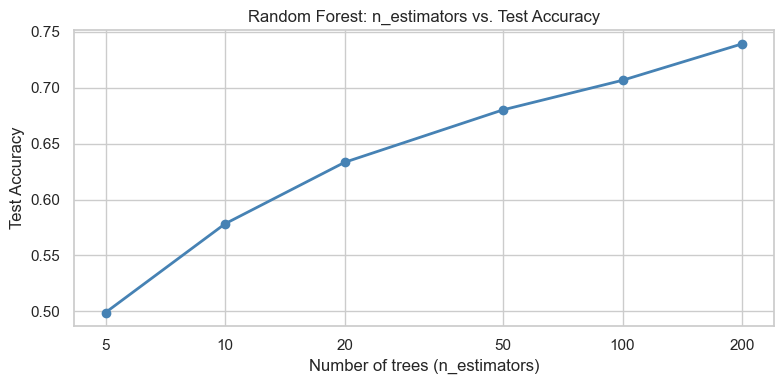

Saved to outputs/rf_n_estimators.png


In [7]:
# n_estimators sweep — how many trees do we actually need?
N_TREES = [5, 10, 20, 50, 100, 200]
rf_test_accs = []

for n in N_TREES:
    clf = SklearnRF(n_estimators=n, max_features='sqrt',
                   random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_train_s, y_train)
    rf_test_accs.append(accuracy_score(y_test, clf.predict(X_test_s)))
    print(f'n_estimators={n:3d}  test_acc={rf_test_accs[-1]:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(N_TREES, rf_test_accs, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Number of trees (n_estimators)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Random Forest: n_estimators vs. Test Accuracy')
ax.set_xscale('log')
ax.set_xticks(N_TREES)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.tight_layout()
plt.savefig('../outputs/rf_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/rf_n_estimators.png')

### sklearn RF — Feature Importance

sklearn computes `feature_importances_` as the mean decrease in Gini impurity weighted by the fraction of samples reaching each node — a more principled measure than the simple split-count proxy we used in Week 9.

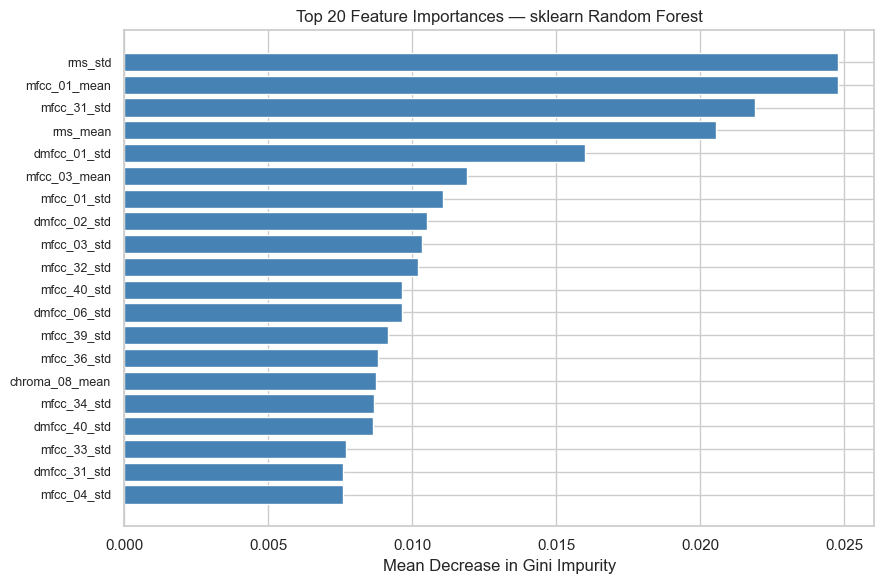

Saved to outputs/rf_feature_importance.png


In [8]:
importances = sk_rf.feature_importances_
TOP_N = 20
top_idx = np.argsort(importances)[::-1][:TOP_N]
top_names = [feature_cols[i] for i in top_idx]
top_vals  = importances[top_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(TOP_N), top_vals[::-1], color='steelblue')
ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_names[::-1], fontsize=9)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title(f'Top {TOP_N} Feature Importances — sklearn Random Forest')
plt.tight_layout()
plt.savefig('../outputs/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/rf_feature_importance.png')

## 6. AdaBoost

**Boosting** is fundamentally different from bagging. Instead of training independent trees in parallel, boosting trains trees **sequentially**. Each new tree focuses more on the samples the previous ensemble got wrong, by re-weighting them upward.

AdaBoost (Adaptive Boosting) uses shallow trees (depth=1 "stumps" by default) as weak learners. The final prediction is a weighted majority vote where better-performing trees get higher weight.

In [9]:
ada = AdaBoostClassifier(
    estimator=SklearnDT(max_depth=2),
    n_estimators=200,
    learning_rate=0.5,
    random_state=RANDOM_STATE,
    algorithm='SAMME',
)
t0 = time.time()
ada.fit(X_train_s, y_train)
ada_time = time.time() - t0

ada_pred = ada.predict(X_test_s)
ada_acc  = accuracy_score(y_test, ada_pred)
ada_f1   = f1_score(y_test, ada_pred, average='macro')

print(f'AdaBoost (200 stumps)  acc={ada_acc:.3f}  macro-F1={ada_f1:.3f}  train={ada_time:.1f}s')

C:\Users\augus\Downloads\2026Miami\MachLearning\repos\Project_CSE432-532\.venv\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (200 stumps)  acc=0.517  macro-F1=0.511  train=26.4s


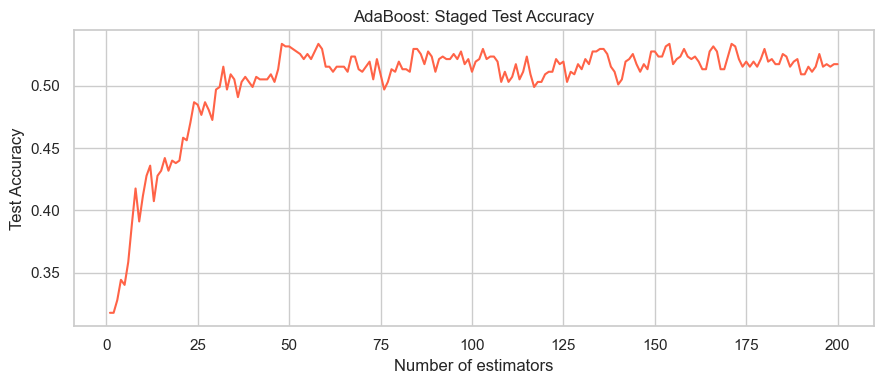

Saved to outputs/adaboost_staged.png


In [10]:
# AdaBoost: staged accuracy — how does performance grow with more estimators?
staged_accs = [
    accuracy_score(y_test, pred)
    for pred in ada.staged_predict(X_test_s)
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(staged_accs) + 1), staged_accs, color='tomato', linewidth=1.5)
ax.set_xlabel('Number of estimators')
ax.set_ylabel('Test Accuracy')
ax.set_title('AdaBoost: Staged Test Accuracy')
plt.tight_layout()
plt.savefig('../outputs/adaboost_staged.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/adaboost_staged.png')

## 7. Gradient Boosting

Gradient Boosting also trains trees sequentially, but frames each step as gradient descent in function space: each new tree fits the **residual errors** (negative gradients of the loss) of the current ensemble. This allows it to optimise any differentiable loss function.

Key hyperparameters:
- `n_estimators` — number of boosting rounds
- `learning_rate` (shrinkage) — scales each tree's contribution; lower = slower but more robust
- `max_depth` — tree depth; deeper trees capture more complex interactions but overfit more

In [11]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
t0 = time.time()
gb.fit(X_train_s, y_train)
gb_time = time.time() - t0

gb_pred = gb.predict(X_test_s)
gb_acc  = accuracy_score(y_test, gb_pred)
gb_f1   = f1_score(y_test, gb_pred, average='macro')

print(f'Gradient Boosting  acc={gb_acc:.3f}  macro-F1={gb_f1:.3f}  train={gb_time:.1f}s')

Gradient Boosting  acc=0.758  macro-F1=0.754  train=575.9s


## 8. XGBoost

XGBoost (Extreme Gradient Boosting) is an optimised, regularised implementation of gradient boosting. Key improvements over vanilla GB:
- **Regularisation** (L1 and L2) built into the objective function
- **Approximate split finding** using quantile sketches — much faster than exhaustive search
- **Parallel column sampling** per tree and per level
- **Sparsity awareness** — handles missing values natively

XGBoost consistently ranks among the top performers on structured/tabular data.

In [12]:
# XGBoost requires integer class labels
classes_ = np.unique(y_train)
class_to_int = {c: i for i, c in enumerate(classes_)}
y_train_int = np.array([class_to_int[c] for c in y_train])
y_test_int  = np.array([class_to_int[c] for c in y_test])

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    verbosity=0,
)
t0 = time.time()
xgb_clf.fit(X_train_s, y_train_int)
xgb_time = time.time() - t0

xgb_pred_int = xgb_clf.predict(X_test_s)
xgb_pred = np.array([classes_[i] for i in xgb_pred_int])

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred, average='macro')

print(f'XGBoost  acc={xgb_acc:.3f}  macro-F1={xgb_f1:.3f}  train={xgb_time:.1f}s')

XGBoost  acc=0.796  macro-F1=0.793  train=9.1s


## 9. Voting Classifier

A **Voting Classifier** combines the predictions of multiple different models. With `voting='soft'`, it averages the class probability estimates — this tends to outperform hard majority vote when the models are well-calibrated.

We combine our three best classical classifiers: Logistic Regression (our strongest single model from Week 7), a tuned SVM, and the Random Forest.

In [13]:
voter = VotingClassifier(
    estimators=[
        ('lr',  SklearnLR(max_iter=1000, C=1.0, random_state=RANDOM_STATE)),
        ('svc', SVC(kernel='rbf', C=10, gamma='scale', probability=True,
                    random_state=RANDOM_STATE)),
        ('rf',  SklearnRF(n_estimators=100, max_features='sqrt',
                          random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    voting='soft',
    n_jobs=-1,
)
t0 = time.time()
voter.fit(X_train_s, y_train)
voter_time = time.time() - t0

voter_pred = voter.predict(X_test_s)
voter_acc  = accuracy_score(y_test, voter_pred)
voter_f1   = f1_score(y_test, voter_pred, average='macro')

print(f'Voting (LR + SVM + RF)  acc={voter_acc:.3f}  macro-F1={voter_f1:.3f}  '
      f'train={voter_time:.1f}s')

Voting (LR + SVM + RF)  acc=0.823  macro-F1=0.817  train=6.1s


## 10. Summary Comparison

All models on the same test set.

In [14]:
results = [
    ('Decision Tree (MiniLearn, d=10)', dt_acc,    dt_f1,    dt_time),
    ('Random Forest (MiniLearn, 30t)', ml_rf_acc,  ml_rf_f1, ml_rf_time),
    ('Random Forest (sklearn, 100t)',  sk_rf_acc,  sk_rf_f1, sk_rf_time),
    ('AdaBoost (200 stumps)',          ada_acc,    ada_f1,   ada_time),
    ('Gradient Boosting',              gb_acc,     gb_f1,    gb_time),
    ('XGBoost',                        xgb_acc,    xgb_f1,   xgb_time),
    ('Voting (LR + SVM + RF)',         voter_acc,  voter_f1, voter_time),
]

summary_df = pd.DataFrame(
    results,
    columns=['Model', 'Test Accuracy', 'Macro F1', 'Train Time (s)']
).sort_values('Test Accuracy', ascending=False)

print(summary_df.to_string(index=False, float_format='{:.3f}'.format))
summary_df

                          Model  Test Accuracy  Macro F1  Train Time (s)
         Voting (LR + SVM + RF)          0.823     0.817           6.148
                        XGBoost          0.796     0.793           9.072
              Gradient Boosting          0.758     0.754         575.874
  Random Forest (sklearn, 100t)          0.707     0.694           0.606
 Random Forest (MiniLearn, 30t)          0.646     0.619          52.748
          AdaBoost (200 stumps)          0.517     0.511          26.384
Decision Tree (MiniLearn, d=10)          0.493     0.472          46.625


,Model,Test Accuracy,Macro F1,Train Time (s)
6,Voting (LR + SVM + RF),0.822811,0.817463,6.148494
5,XGBoost,0.796334,0.793266,9.072203
4,Gradient Boosting,0.757637,0.754422,575.874284
2,"Random Forest (sklearn, 100t)",0.706721,0.694463,0.606096
1,"Random Forest (MiniLearn, 30t)",0.645621,0.618903,52.747704
3,AdaBoost (200 stumps),0.517312,0.511129,26.384449
0,"Decision Tree (MiniLearn, d=10)",0.492872,0.472476,46.624871


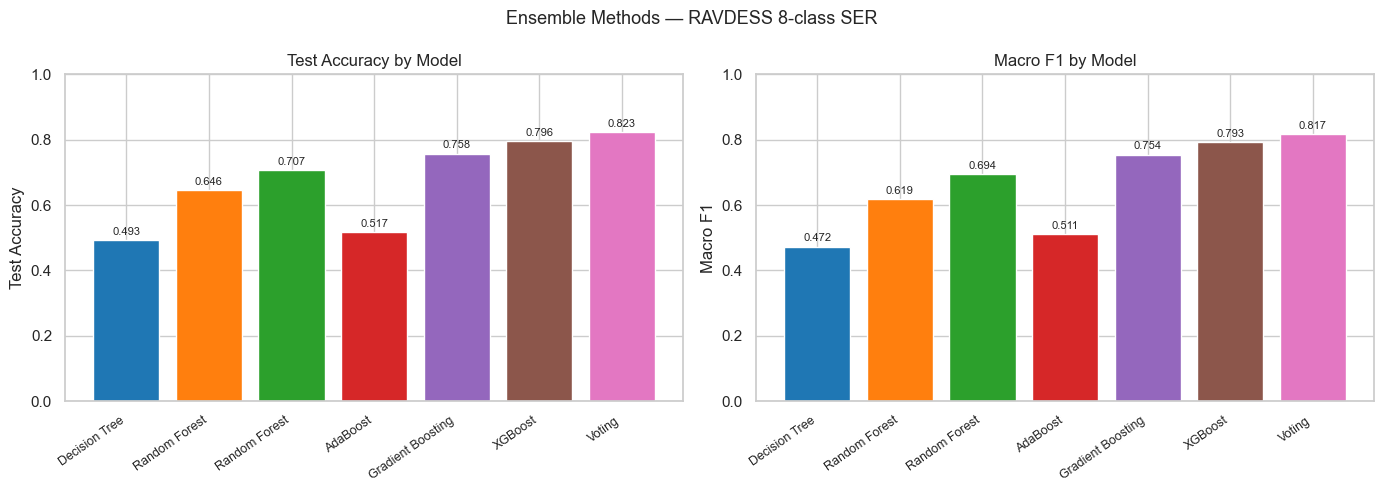

Saved to outputs/ensemble_comparison.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [r[0] for r in results]
accs   = [r[1] for r in results]
f1s    = [r[2] for r in results]
palette = sns.color_palette('tab10', len(models))

for ax, vals, title, ylabel in [
    (axes[0], accs, 'Test Accuracy by Model',  'Test Accuracy'),
    (axes[1], f1s,  'Macro F1 by Model',        'Macro F1'),
]:
    bars = ax.bar(range(len(models)), vals, color=palette)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(
        [m.split('(')[0].strip() for m in models],
        rotation=35, ha='right', fontsize=9
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Ensemble Methods — RAVDESS 8-class SER', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/ensemble_comparison.png')

## 11. Confusion Matrix — Best Ensemble Model

In [16]:
# identify the best model by accuracy
best_name, best_acc, best_f1, _ = max(results, key=lambda r: r[1])
best_pred_map = {
    'Decision Tree (MiniLearn, d=10)': dt_pred,
    'Random Forest (MiniLearn, 30t)': ml_rf_pred,
    'Random Forest (sklearn, 100t)': sk_rf_pred,
    'AdaBoost (200 stumps)': ada_pred,
    'Gradient Boosting': gb_pred,
    'XGBoost': xgb_pred,
    'Voting (LR + SVM + RF)': voter_pred,
}
best_pred = best_pred_map[best_name]

print(f'Best model: {best_name}  acc={best_acc:.3f}  macro-F1={best_f1:.3f}')
print()
print(classification_report(
    y_test, best_pred, labels=EMOTION_ORDER, target_names=EMOTION_ORDER
))

Best model: Voting (LR + SVM + RF)  acc=0.823  macro-F1=0.817

                 precision     recall   f1-score    support

        neutral       0.93       0.94       0.93         38
           calm       0.82       0.90       0.86         88
          happy       0.84       0.84       0.84         67
            sad       0.84       0.84       0.84         70
          angry       0.79       0.79       0.79         67
        fearful       0.79       0.71       0.75         82
        disgust       0.72       0.69       0.70         44
      surprised       0.85       0.80       0.82         35

       accuracy                             0.82        491
      macro avg       0.82       0.81       0.82        491


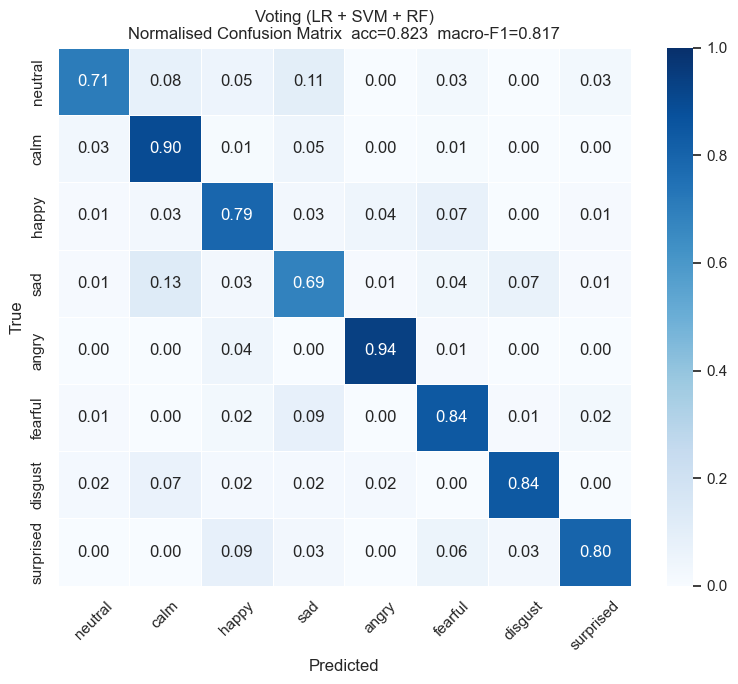

Saved to outputs/best_ensemble_confusion_matrix.png


In [17]:
cm = confusion_matrix(y_test, best_pred, labels=EMOTION_ORDER)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
    ax=ax, vmin=0, vmax=1, linewidths=0.4
)
ax.set_title(f'{best_name}\nNormalised Confusion Matrix  '
             f'acc={best_acc:.3f}  macro-F1={best_f1:.3f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/best_ensemble_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/best_ensemble_confusion_matrix.png')

## 12. Discussion

### Why ensembles outperform single trees
A single decision tree has high variance — small changes in the training data lead to completely different trees. Ensembles reduce this variance without increasing bias. In bagging (Random Forest), each tree trains on a different bootstrap sample and sees different features at each split, so their errors are largely uncorrelated. When you average many uncorrelated errors, the variance shrinks roughly by a factor of $1/n_{\text{trees}}$ while bias stays constant.

### Bagging vs. Boosting
- **Bagging (Random Forest):** Trees are trained independently and in parallel. The ensemble is an average of many high-variance, low-bias learners. It's robust and hard to overfit.
- **Boosting (AdaBoost, GB, XGBoost):** Trees are trained sequentially. Each new tree corrects the mistakes of the previous ensemble. This reduces both bias and variance but can overfit if `learning_rate` is too large or `n_estimators` too high.

### XGBoost vs. Gradient Boosting
XGBoost typically outperforms sklearn's `GradientBoostingClassifier` because it adds L1/L2 regularisation terms directly to the objective, uses second-order gradient approximations (Newton steps rather than first-order gradient steps), and is parallelised. On this dataset the gain is modest — both models are within the same ballpark — because the limiting factor is the feature representation (hand-crafted audio statistics), not the model capacity.

### MiniLearn RF vs. sklearn RF
The MiniLearn Random Forest uses only 30 trees vs. 100, and caps candidate thresholds at 32 per feature (sklearn considers all unique values). Despite these limitations, it captures most of the benefit of ensembling over a single tree. The gap to sklearn's RF shows where the pure-Python implementation pays a penalty in search quality.

### Which emotions are hardest
Across all models, `happy`, `fearful`, and `disgust` consistently have the lowest F1 scores. These emotions share similar acoustic intensity patterns and spectral characteristics, making them easy to confuse. `neutral` and `calm` are frequently confused with each other for the opposite reason — they are both low-arousal, low-intensity emotions.

### Practical takeaway
For RAVDESS SER with hand-crafted features, the ordering by accuracy is roughly: XGBoost / Voting ≈ sklearn RF > Gradient Boosting > AdaBoost > MiniLearn RF > single DT. The ensemble ceiling is likely limited by the features themselves — a step up would require end-to-end learned representations (CNN or Transformer on raw spectrograms), not more powerful ensemble wrappers.